<a href="https://colab.research.google.com/github/UXDynamicSolution/MineriaDatosDuocPAO/blob/main/material_de_refozamiento_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Material de Reforzamiento - K-Means - Desarrollado por Carlos Muñoz Salgado.
Este material es parte del desarrollo del proyecto individual Legal GPT y tiene como propósito analizar agrupaciones desconocidas en el modelo juridico donde se realizará Fine Tuning a un QWENT para, poder encontrar sesgos y relaciones ocultas.





K-Means es un algoritmo de machine learning o minería de datos, de aprendizaje no supervisado, utilizado para encontrar agrupaciones de datos (clusters) en datasets desordenados. A diferencia de los modelos de aprendizaje supervisado que hemos visto en clases, donde le decimos específicamente qué debe clasificar o predecir, aquí le pasamos datos "crudos" o, dicho de otra forma, datos no etiquetados, y el modelo se encarga de agruparlos buscando similitudes matemáticas o distancias euclidianas entre sí.

**K-Means** usa la distancia euclidiana para encontrar cercanía física y agrupar valores numéricos tabulares.

**Los LLMs** usan representaciones espaciales (Embeddings) y prefieren medir el ángulo entre vectores (Similitud del Coseno) para entender si dos textos apuntan hacia la misma idea o contexto semántico.

Para aplicar este modelo, utilizaré un dataset de noticias del diario constitucional, que fue scrappeado hasta el 2023, y buscar agrupaciones de datos.


La cinta métrica (Distancia Euclidiana): El ayudante usa una regla para medir el espacio físico o numérico entre caja y caja.

El balancín de la Disimilaridad: El ayudante entiende la regla de oro: la distancia mide qué tan distintas son las cosas (disimilaridad). Funciona como un balancín:

Si la disimilaridad sube (la regla marca mucha distancia), la similitud baja (las cajas no tienen nada que ver y van a grupos distintos).

Si la disimilaridad baja (la regla marca una distancia pequeñita), la similitud sube (las cajas son casi idénticas y se agrupan juntas).

In [ ]:
!pip install kneed

In [ ]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

####
#LIBRERIAS DE NLP TOLKIT
####
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator #  clase para detectar los n de codo

nltk.download('stopwords')
print("Entorno configurado correctamente.")
# LAS STOPWORDS SON PALABRAS MUY FRECUENTES EN UN IDIOMA QUE EN SI, PARA LOS MODELOS,
# NO APORTAN MUCHO CONTENIDO SEMANTICO A LOS TEXTOS, COMO LOS CONECTORES.

Entorno configurado correctamente.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
archivo_unificado = "noticias_unificadas.txt" #dataset, noticas scrappeadas de DiarioConstitucional

if not os.path.exists(archivo_unificado):
    print("Error: No se encuentra el archivo unificado.")
else:
    with open(archivo_unificado, "r", encoding="utf-8") as f:
        data_completa = f.read()

    # Expresion regular para extraer bloques
    patron = r"=== INICIO: (.*?) ===\n(.*?)\n=== FIN ==="
    bloques = re.findall(patron, data_completa, re.DOTALL)

    df = pd.DataFrame(bloques, columns=["archivo_origen", "contenido_noticia"])
    df["contenido_noticia"] = df["contenido_noticia"].str.strip()

    print("DataFrame creado. Total de noticias:", df.shape[0])
    display(df.head())

DataFrame creado. Total de noticias: 690


,archivo_origen,contenido_noticia
0,104_proyectos_fueron_publicados_como_ley_en_un...,104 proyectos fueron publicados como ley en un...
1,10_actitudes_que_como_abogado_me_agradan_de_un...,10 actitudes que como abogado me agradan de un...
2,10_consejos_para_proteger_la_reputacion_online...,10 consejos para proteger la reputación «onlin...
3,10_consejos_para_proteger_la_reputacion_person...,10 consejos para proteger la reputación person...
4,10_libros_no_estrictamente_juridicos_que_todo_...,10 libros no estrictamente jurídicos que todo ...


--- Estadisticas del Corpus ---


,caracteres,palabras
count,690.0,690.0
mean,3698.0,587.0
std,2486.0,393.0
min,564.0,89.0
25%,2254.0,353.0
50%,3254.0,518.0
75%,4304.0,677.0
max,22633.0,3541.0


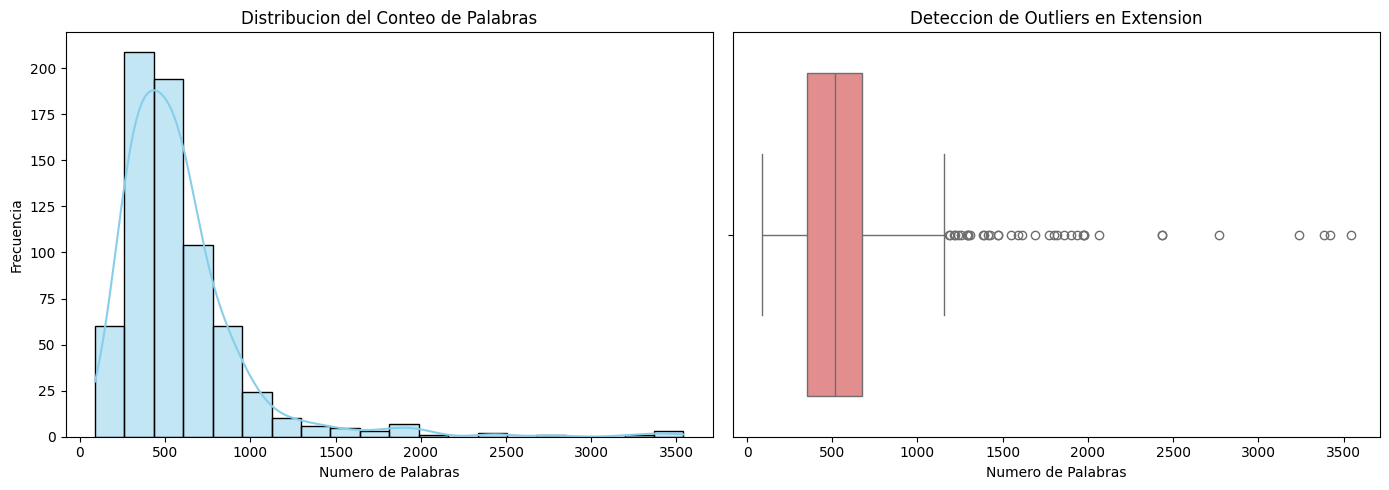

In [ ]:
df['caracteres'] = df['contenido_noticia'].astype(str).apply(len)
df['palabras'] = df['contenido_noticia'].astype(str).apply(lambda x: len(x.split()))

print("--- Estadisticas del Corpus ---")
display(df[['caracteres', 'palabras']].describe().round())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['palabras'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribucion del Conteo de Palabras')
axes[0].set_xlabel('Numero de Palabras')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=df['palabras'], ax=axes[1], color='lightcoral')
axes[1].set_title('Deteccion de Outliers en Extension')
axes[1].set_xlabel('Numero de Palabras')

plt.tight_layout()
plt.show()

In [ ]:
stop_words_es = stopwords.words('spanish')

# Terminos juridicos redundantes
palabras_extra = ['derecho', 'tribunal', 'articulo', 'ley', 'corte', 'constitucional', 'noticia', 'asi', 'cada']
stop_words_es.extend(palabras_extra)

vectorizer = TfidfVectorizer(stop_words=stop_words_es, max_df=0.85, min_df=2)
X_tfidf = vectorizer.fit_transform(df['contenido_noticia'])

print("Matriz TF-IDF construida.")
print("Dimension de los datos:", X_tfidf.shape)

Matriz TF-IDF construida.
Dimension de los datos: (690, 11199)


# Determinación del Número de Cluster optimo

**Metodo del Codo (Elbow Method):**
Es el analisis de "costo-beneficio". Imagina que agregar mas clusters es como gastar mas recursos: el codo es el punto exacto donde seguir agregando grupos ya no te da una mejora significativa en la precision. Es simplemente el punto donde la curva del grafico se quiebra, como un codo humano, indicando que ahi debes detenerte.

**Metodo de la Silueta (Silhouette Method):**
Es la prueba de "calidad y separacion". Mide que tan bien acomodado esta cada punto dentro de su grupo y que tan lejos esta de los grupos vecinos. Si el valor es alto, significa que tus grupos son solidos, estan compactos por dentro y estan bien separados de los demas.

In [ ]:
sse = []
silhouette_scores = []
rango_k = range(2, 15)

print("Calculando metricas...")

for k in rango_k:
    # Crear el modelo con k-clusters
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)

    # Ajustar el modelo a los datos
    kmeans_eval.fit(X_tfidf)

    # Obtener las etiquetas
    labels = kmeans_eval.labels_

    # Obtener el valor de la funcion objetivo
    sse.append(kmeans_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_tfidf, labels))

# Clase que sirve para calcular el codo de forma automatica
kl = KneeLocator(rango_k, sse, curve="convex", direction="decreasing")
print("El codo esta en k =", kl.elbow)



Calculando metricas...
El codo esta en k = 13


El codo esta en k = 13


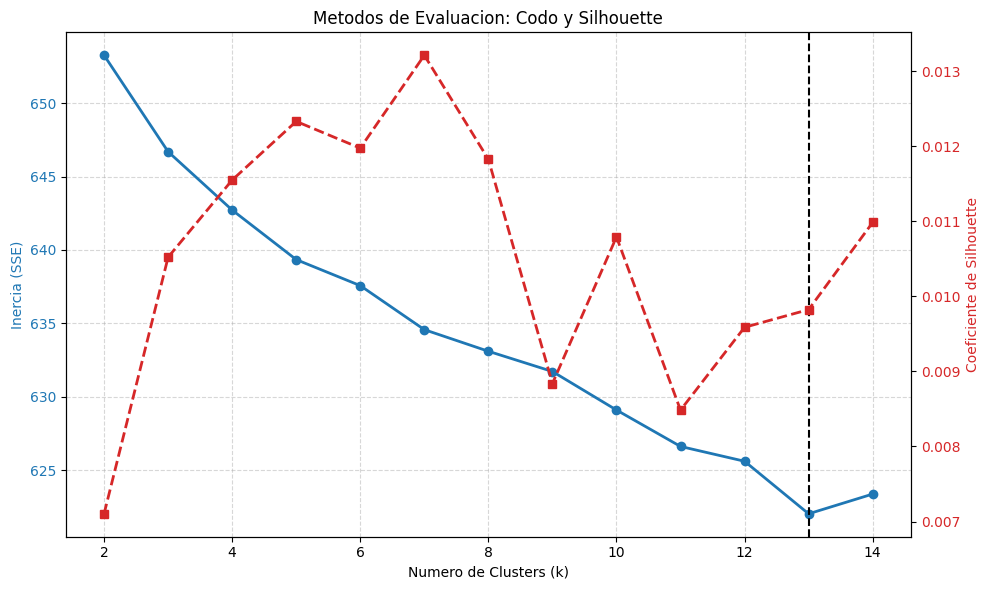

In [ ]:
# Detectamos el codo de forma automatica
kl = KneeLocator(rango_k, sse, curve="convex", direction="decreasing")
print("El codo esta en k =", kl.elbow)

# Graficamos ambos metodos para tomar la decision
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje izquierdo para el Codo (Inercia)
color = 'tab:blue'
ax1.set_xlabel('Numero de Clusters (k)')
ax1.set_ylabel('Inercia (SSE)', color=color)
ax1.plot(rango_k, sse, marker='o', color=color, linewidth=2, label='Inercia')
if kl.elbow:
    ax1.axvline(x=kl.elbow, color='black', linestyle='--', label=f'Codo detectado (k={kl.elbow})')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje derecho para la Silueta
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silhouette', color=color)
ax2.plot(rango_k, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Metodos de Evaluacion: Codo y Silhouette')
fig.tight_layout()
plt.show()

In [ ]:
k_optimo = kl.elbow
modelo = KMeans(n_clusters=k_optimo, init='k-means++', max_iter=300, n_init=10, random_state=42)

# El modelo aprende la estructura de los datos sin etiquetas
modelo.fit(X_tfidf)

# Asignamos cada noticia a un cluster usando el metodo predict
df['cluster'] = modelo.predict(X_tfidf)

# Extraccion de resultados
centroides = modelo.cluster_centers_

print("--- Cantidad de noticias asignadas por cluster ---")
print(df['cluster'].value_counts().sort_index())
print("\n" + "="*50 + "\n")

terminos = vectorizer.get_feature_names_out()
centroides_ordenados = centroides.argsort()[:, ::-1]

print("--- Topicos detectados (Top 10 palabras con mayor peso) ---")
for i in range(k_optimo):
    print(f"\nCLUSTER {i}:")
    top_terminos = [terminos[ind] for ind in centroides_ordenados[i, :10]]
    print(", ".join(top_terminos))

    # Extraemos muestras para validar el cluster
    ejemplos = df[df['cluster'] == i]['archivo_origen'].head(3).tolist()
    #print(f"   Archivos ejemplo: {ejemplos}")

--- Cantidad de noticias asignadas por cluster ---
cluster
0      18
1      56
2      42
3      60
4      98
5      59
6      27
7     122
8      25
9      47
10     55
11     15
12     66
Name: count, dtype: int64


--- Topicos detectados (Top 10 palabras con mayor peso) ---

CLUSTER 0:
partido, partidos, lista, político, comisión, candidatos, udi, consejo, electoral, transparencia

CLUSTER 1:
sentencia, casación, nulidad, fallo, recurso, civil, suprema, demanda, artículo, código

CLUSTER 2:
requerimiento, inaplicabilidad, gestión, penal, pendiente, requirente, inadmisible, precepto, artículo, norma

CLUSTER 3:
dictamen, contraloría, cgr, artículo, contralor, resolución, general, república, contrata, 19

CLUSTER 4:
protección, suprema, sentencia, recurrente, recurso, acción, amparo, fallo, santiago, recurrida

CLUSTER 5:
proyecto, comisión, diputados, iniciativa, cámara, moción, discusión, modifica, senado, obligatorio

CLUSTER 6:
transparencia, información, cplt, consejo, pública, 20

Fijense bien en lo siguiente, ambos metodos llegaron al mismo n° de cluster, algo extremadamente dificil y poco frecuente, esto se da porque en nuestro conjunto de datos, los grupos ocultos estan bien "marcados" o "definidos" ya que por lo general, suelen contradecirse.

# Sin que nadie le enseñara leyes al modelo kmeans, la matemática dividió la realidad del país en cuatro pilares lógicos: Quién hace las reglas (El Poder), quién pelea por trabajo o plata (La Vida Diaria), quién exige ser defendido (Los Derechos) y quién vigila que el sistema funcione (El Estado).

> *"Hacerlos pensar en clases es la única forma de evitar que sean reemplazados por una IA el día de mañana y, al mismo tiempo, prepararlos para los escenarios inciertos del futuro en un mundo que está cambiando"*